----------------------------------------------------------------------------------------------------

# ***FastAPI - Operações CRUD assíncrona em API RESTful***

----------------------------------------------------------------------------------------------------

# ***1. READ - Leitura de posts*** 

## ***1.1 'post.py' na pasta 'controllers':***

No arquivo 'post.py', o seu código será o seguinte:

In [ ]:
from fastapi import Response, status, APIRouter

from app.main import database
from schemas.post import PostIn
from views.post import PostOut
from models.post import posts

router = APIRouter(prefix= "/posts")

@router.post('/', status_code= status.HTTP_201_CREATED, response_model = PostOut)
def create_post(post: PostIn):
    # fake_db.append(post.model_dump())
    return post

@router.get('/', response_model = list[PostOut])
def read_posts(response: Response, published: bool, limit: int, skip: int = 0, ):
    # criando a querry
    querry = posts.select()
    return database.fetch_all(querry)

### ***1.1.1. Erro de 'circular import'***

O 'main' esta fazendo controller post. Podemos fazê-lo um app factory que apenas ordena execuções de códigos que estão em outras pastas, portanto ser responsável apenas para rodar o projeto ou separamos essa parte que controla o 'controller' 'post'.

O professor escolheu fazer  a segunda opção para fins didáticos.

## ***1.2 Segunda opção - Criaçaõ do 'database.py'***

Vamos criar um novo arquivo de nome 'database.py' e aplicaremos o seguinte trecho de código do arquivo 'main.py' nele e, consequentemente, removeremos do arquivo main:

In [ ]:
import databases 
import sqlalchemy 

DATABASE_URL = 'sqlite:///./blog.db'

# cria database
database = databases.Database(DATABASE_URL)
# instanciando a classe SQLalchemmy
metadata = sqlalchemy.MetaData()
engine = sqlalchemy.create_engine(DATABASE_URL, connect_args = {"check_same_thread": False})

## ***1.3 Segunda opção - Correção do arquivo 'main.py'***

Feito o arquivo 'database.py' e o trecho aplicado, vamos no arquivo 'main.py' e faremos a seguinte atualização:

In [ ]:
from contextlib import asynccontextmanager

from fastapi import FastAPI
from controllers import post
from app.database import database, engine, metadata


@asynccontextmanager
async def lifespan(app: FastAPI):
    from models.post import posts # noqa

    await database.connect()
    # utiliza a engine:
    metadata.create_all(engine)
    yield
    await database.disconnect()

app = FastAPI(lifespan= lifespan)
app.include_router(post.router)


### ***1.3.1. Erro de 'circular import' novamente***

Para corrigirmos isso, devemos ir na pasta 'models' e no arquivo 'posts,py' e fazer a próxima alteração.

## ***1.4 Segunda opção - Correção do arquivo 'post.py' em 'models'***

In [ ]:
import sqlalchemy
from app.database import metadata # atualização é feita aqui

posts = sqlalchemy.Table(
    "posts",
    metadata,
    sqlalchemy.Column("id", sqlalchemy.Integer, primary_key= True),
    sqlalchemy.Column("title", sqlalchemy.String(150), nullable=False),
    sqlalchemy.Column("content", sqlalchemy.String, nullable = False),
    sqlalchemy.Column("published_at", sqlalchemy.DateTime, nullable = True),
    sqlalchemy.Column("published", sqlalchemy.Boolean, default = False)

)

## ***1.5 Segunda opção - Correção do arquivo 'post.py' em 'controllers'***

In [ ]:
from fastapi import Response, status, APIRouter

from app.database import database # correção necessária
from schemas.post import PostIn
from views.post import PostOut
from models.post import posts

router = APIRouter(prefix= "/posts")

@router.post('/', status_code= status.HTTP_201_CREATED, response_model = PostOut)
def create_post(post: PostIn):
    # fake_db.append(post.model_dump())
    return post

@router.get('/', response_model = list[PostOut])
def read_posts(response: Response, published: bool, limit: int, skip: int = 0, ):
    # criando a querry
    querry = posts.select()
    return database.fetch_all(querry)

### ***1.5.1. ERRO - Interal Server***

O seguinte erro é declarado ao tentarmos fazer um request com o arquivo 'api-test.http':

    HTTP/1.1 500 Internal Server Error
    date: Mon, 27 Apr 2026 18:16:16 GMT
    server: uvicorn
    content-length: 21
    content-type: text/plain; charset=utf-8
    connection: close

    Internal Server Error

Ele pede uma lista válida. Para corrigirmos, faremos o passo seguinte:

## ***1.6. Segunda opção - Conexão Assíncrona necessária***

O erro pede uma lista válida. Isso ocorre justamente porque o processo que ele executa não é assíncrono. É aqui que corrigiremos isso.

### ***1.6.1. Adicionamos a palavra reservada 'async' em 'post.py' do 'controller'***

In [ ]:
from fastapi import Response, status, APIRouter

from app.database import database
from schemas.post import PostIn
from views.post import PostOut
from models.post import posts

router = APIRouter(prefix= "/posts")

@router.get('/', response_model = list[PostOut])
async def read_posts(response: Response, published: bool, limit: int, skip: int = 0, ): # aqui
    querry = posts.select()
    return database.fetch_all(querry)

@router.post('/', status_code= status.HTTP_201_CREATED, response_model = PostOut)
def create_post(post: PostIn):
    # fake_db.append(post.model_dump())
    return post


Obs.: O professor mudou a ordem de execução, colocando o read_posts antes do create_posts.

## ***1.6. Segunda opção - Limpando os códigos depreciados***

In [ ]:
from fastapi import status, APIRouter

from app.database import database
from schemas.post import PostIn
from views.post import PostOut
from models.post import posts

router = APIRouter(prefix= "/posts")

@router.get('/', response_model = list[PostOut])
async def read_posts(published: bool, limit: int, skip: int = 0, ):
    # criando a querry
    querry = posts.select()
    return database.fetch_all(querry)

@router.post('/', status_code= status.HTTP_201_CREATED, response_model = PostOut)
def create_post(post: PostIn):
    # fake_db.append(post.model_dump())
    return post


----------------------------------------------------------------------------------------------------

# ***2. CREATE - Criação de posts:*** 

## ***2.1 'post.py' na pasta 'controllers':***

In [ ]:
from fastapi import status, APIRouter

from app.database import database
from schemas.post import PostIn
from views.post import PostOut
from models.post import posts

router = APIRouter(prefix= "/posts")

@router.get('/', response_model = list[PostOut])
async def read_posts(published: bool, limit: int, skip: int = 0, ):
    # criando a querry
    querry = posts.select()
    return database.fetch_all(querry)

@router.post('/', status_code= status.HTTP_201_CREATED, response_model = PostOut)
async def create_post(post: PostIn):
    #atualizando criacao de posts
    command = posts.insert().values(title = post.title, content = post.content, published_at = post.published_at, published = post.published)

    last_id = await database.execute(command)
    # fake_db.append(post.model_dump())
    return post


## ***2.2 'post.py' na pasta 'views':***

In [ ]:
from datetime import datetime
from pydantic import BaseModel


# responsável pela detecção da saída:
class PostOut(BaseModel):
    id: int # adicionamos o 'id'
    title: str
    content: str
    published_at: datetime | None

## ***2.3 'post.py' na pasta 'controllers':***

In [ ]:
from fastapi import status, APIRouter

from app.database import database
from schemas.post import PostIn
from views.post import PostOut
from models.post import posts

router = APIRouter(prefix= "/posts")

@router.get('/', response_model = list[PostOut])
async def read_posts(published: bool, limit: int, skip: int = 0, ):
    # criando a querry
    querry = posts.select()
    return database.fetch_all(querry)

@router.post('/', status_code= status.HTTP_201_CREATED, response_model = PostOut)
async def create_post(post: PostIn):
    #atualizando criacao de posts
    command = posts.insert().values(title = post.title, content = post.content, published_at = post.published_at, published = post.published)

    last_id = await database.execute(command)
    return {**post.model_dump(), "id": last_id} # alteração necessária


## ***2.4. Atualizando o corpo do POST (CREATE) no 'FlashPost'***

Como esta declarado na imagem abaixo, atualizamos o JSON do arquivo com o seguinte trecho:

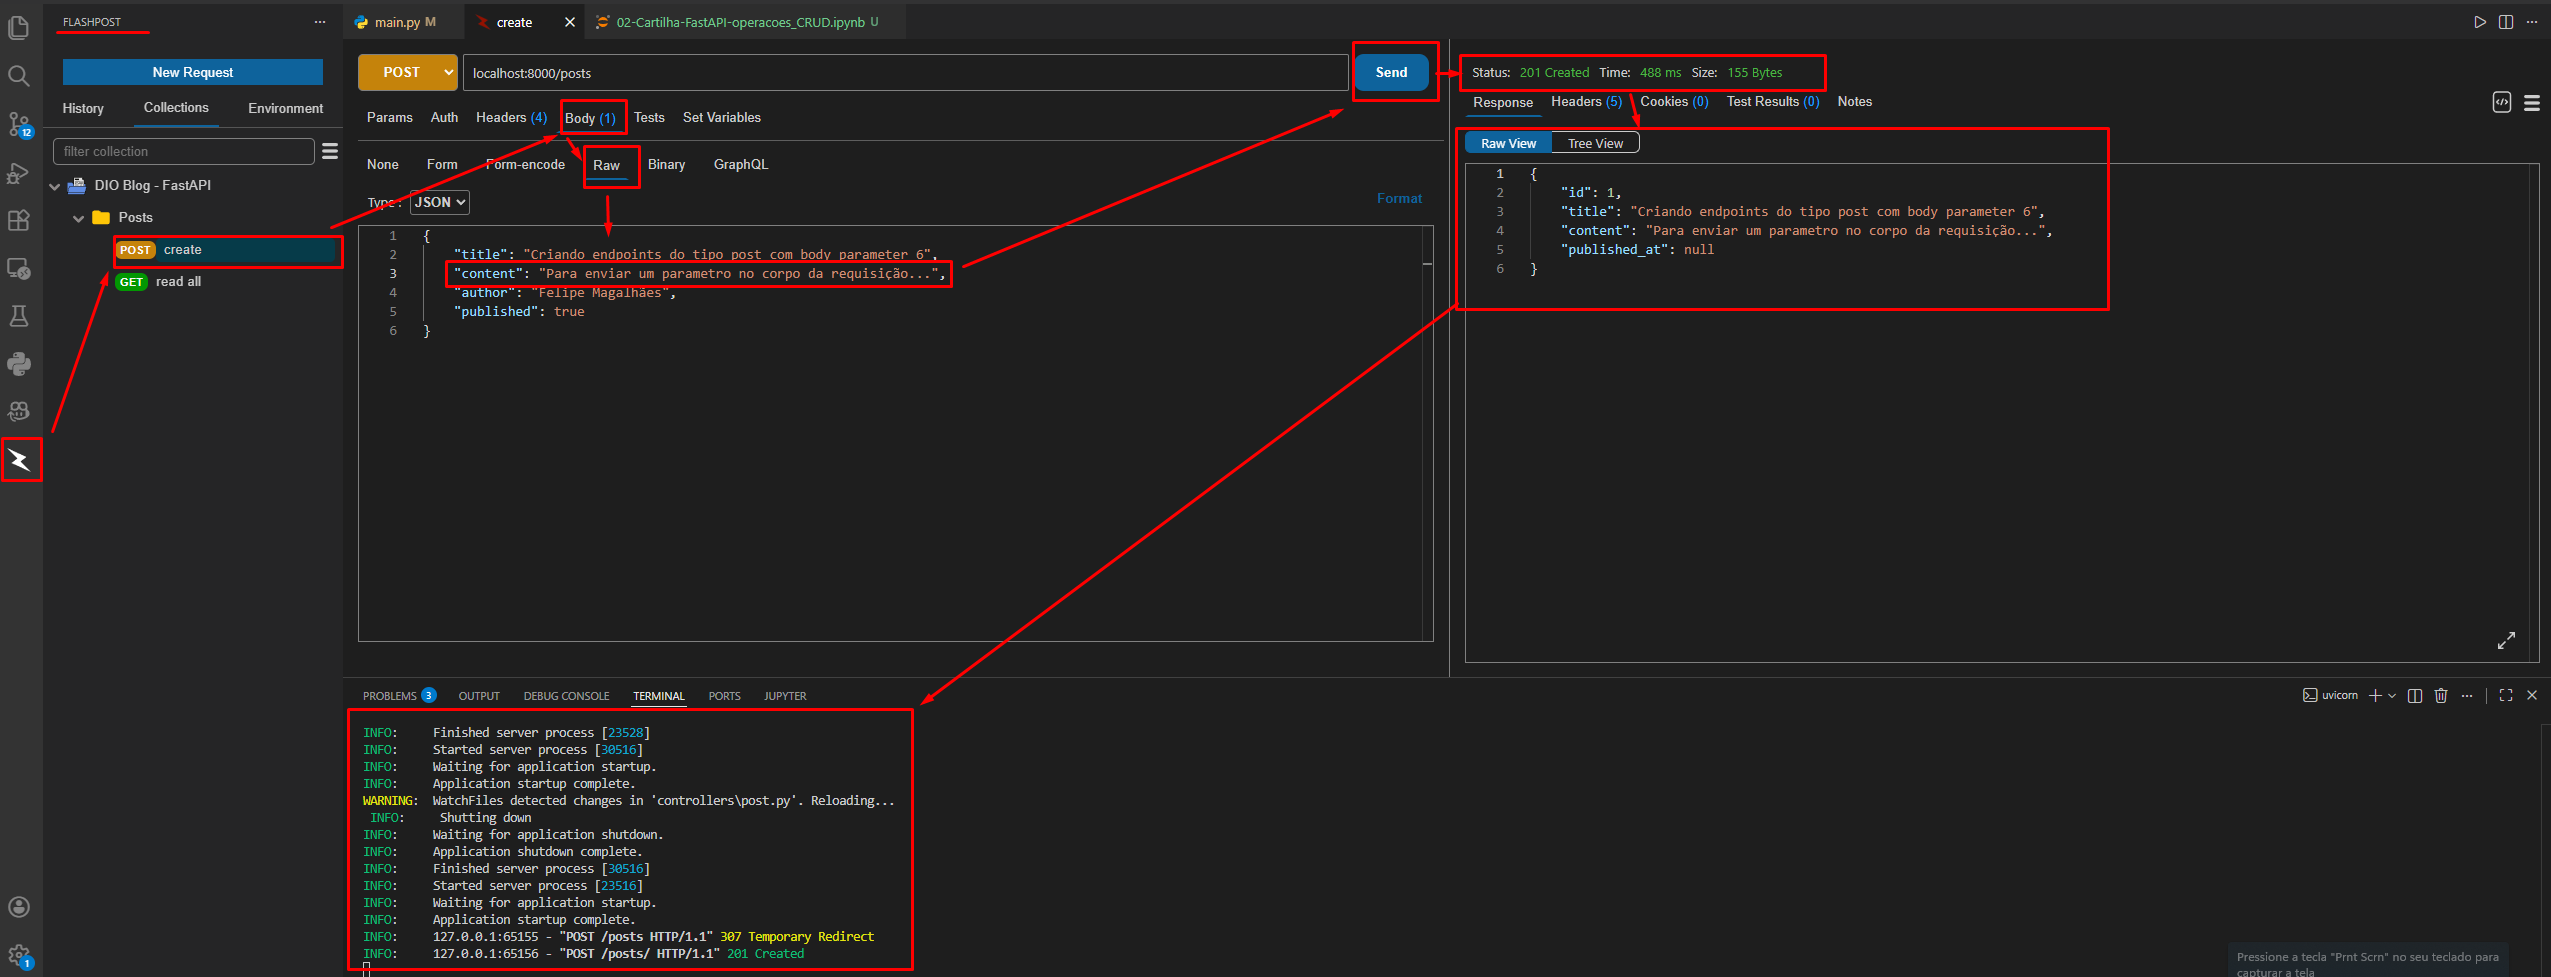

    "content": "Para enviar um parametro no corpo da requisição...", 

## ***2.5. Confirmando alterações no Banco de Dados 'blog.db'***

As alterações foram realizadas e enviadas ao banco de dados, como podemos ver a seguir:

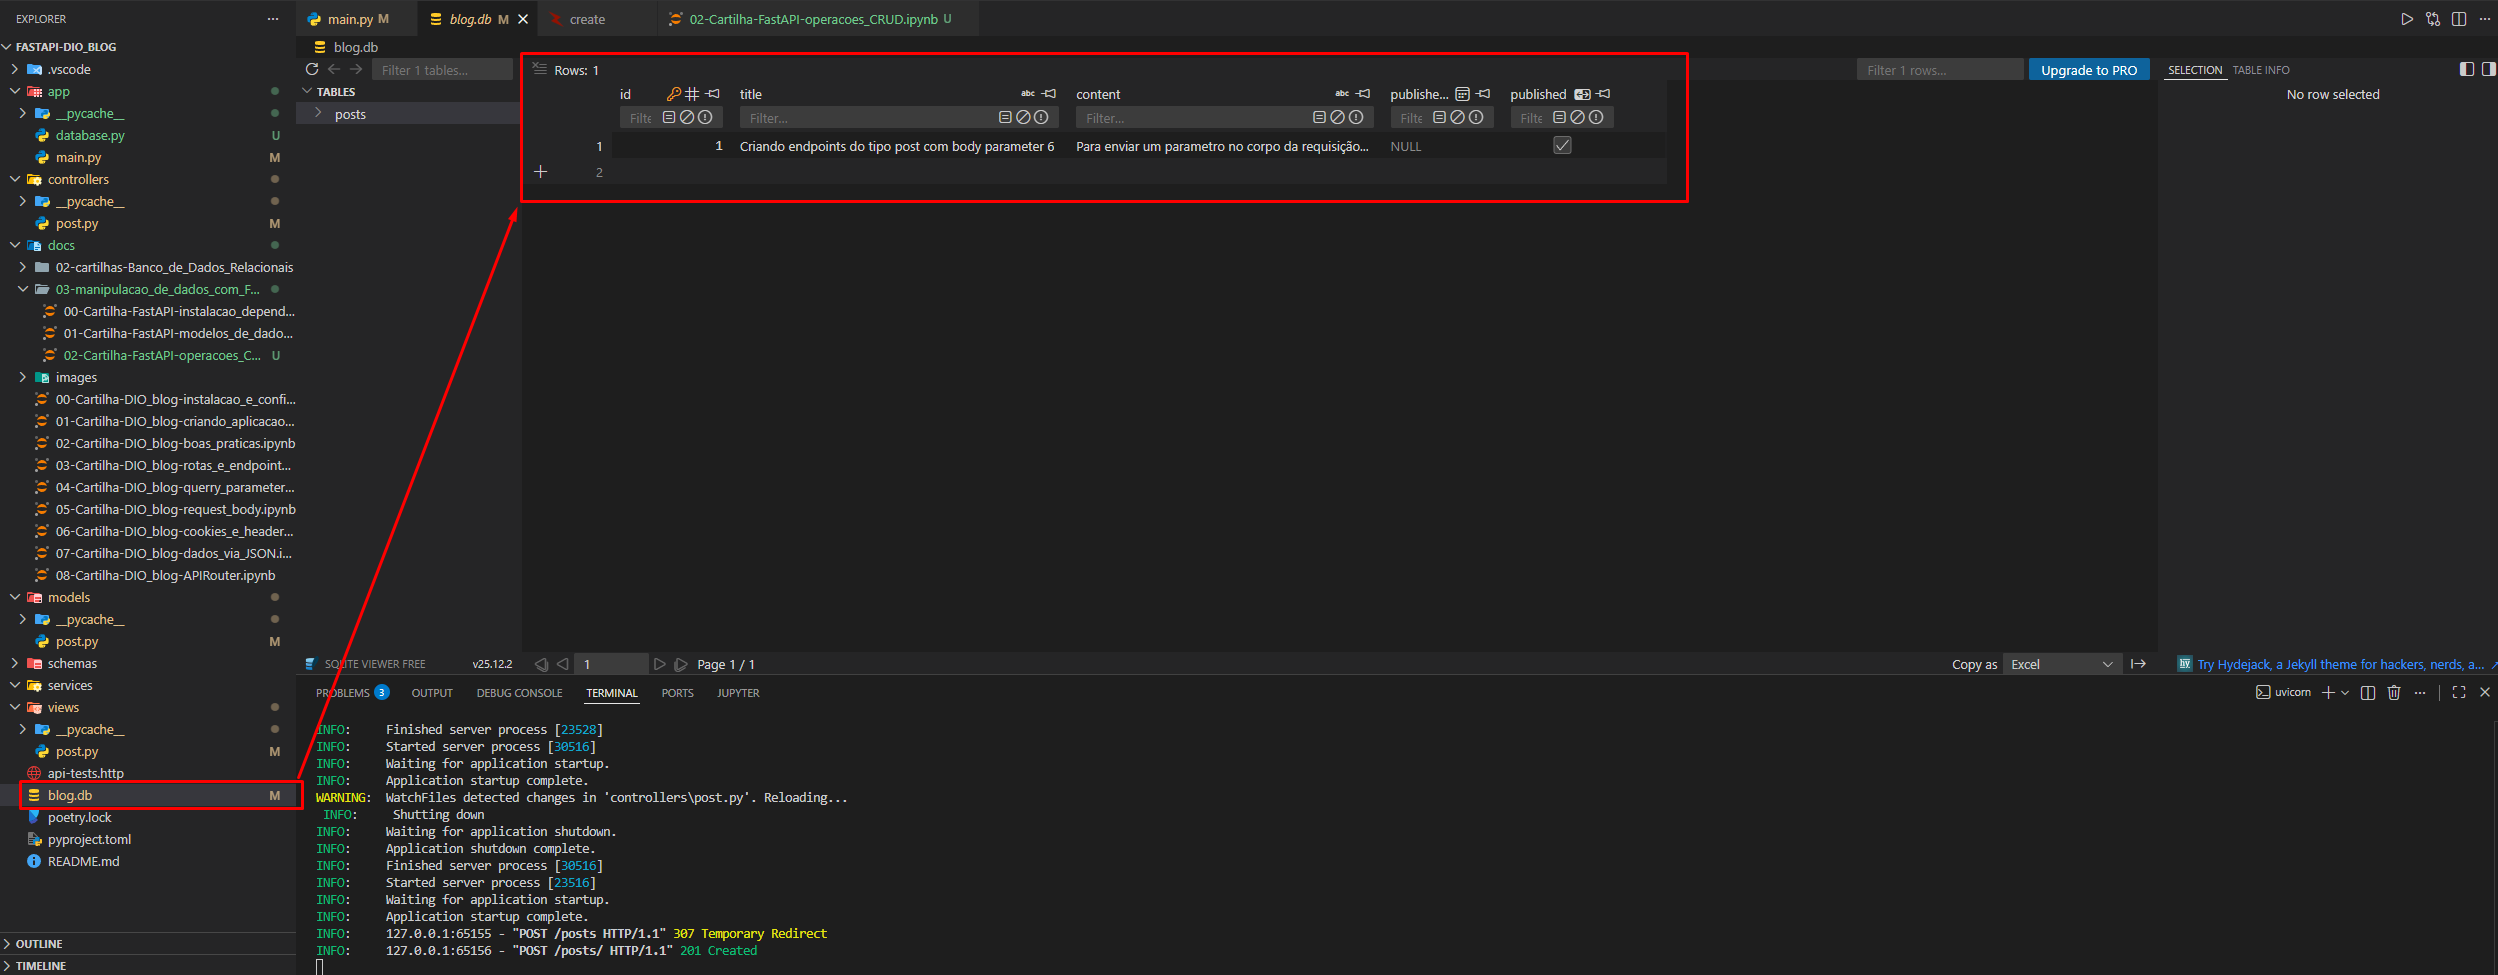

# ***3. Corrigindo erro***

Ocorreu um erro simples de resolver.

O 'GET' (READ) dava um erro de 'Internet Error'. Esta ligado ao problema da conexão assíncrona que adicionamos nesta aula.

Soluçao:
Simplimente adicione a palavra reservada 'await' no arquivo 'post.py', na pasta 'controller'.

In [ ]:
from fastapi import status, APIRouter

from app.database import database
from schemas.post import PostIn
from views.post import PostOut
from models.post import posts

router = APIRouter(prefix= "/posts")

@router.get('/', response_model = list[PostOut])
async def read_posts(published: bool, limit: int, skip: int = 0, ):
    # criando a querry
    querry = posts.select()
    return await database.fetch_all(querry) # simplesmente adicione 'await'

@router.post('/', status_code= status.HTTP_201_CREATED, response_model = PostOut)
async def create_post(post: PostIn):
    #atualizando criacao de posts
    command = posts.insert().values(title = post.title, content = post.content, published_at = post.published_at, published = post.published)

    last_id = await database.execute(command)
    return {**post.model_dump(), "id": last_id}
